# MIS 451 – Machine Learning for Business
## Group Project: Classification – Business Prediction Modeling
### Predicting Online Shoppers' Purchasing Intention

---

**Dataset:** Online Shoppers Purchasing Intention Dataset  
**Source:** UCI Machine Learning Repository  
**Citation:** Sakar, C. O., & Kastro, Y. (2018). *Online Shoppers Purchasing Intention Dataset*. UCI Machine Learning Repository. https://doi.org/10.24432/C5F88Q



---
## Section 0 — Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



import warnings
warnings.filterwarnings('ignore')

# Data Preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Model Selection
from sklearn.model_selection import train_test_split, cross_val_score

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors    import KNeighborsClassifier
from sklearn.ensemble     import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Display settings
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize']    = (10, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

print('All libraries imported successfully.')

All libraries imported successfully.



###  Target Variable

| Value | Meaning |
|---|---|
| `1` (True) | Session ended with a completed purchase |
| `0` (False) | Session ended without a purchase |

###  Feature Descriptions

| Feature | Type | Description |
|---|---|---|
| `Administrative` | Numeric | Number of administrative pages visited in the session |
| `Administrative_Duration` | Numeric | Total time (seconds) spent on administrative pages |
| `Informational` | Numeric | Number of informational pages visited |
| `Informational_Duration` | Numeric | Total time (seconds) spent on informational pages |
| `ProductRelated` | Numeric | Number of product-related pages visited |
| `ProductRelated_Duration` | Numeric | Total time (seconds) spent on product-related pages |
| `BounceRates` | Numeric | % of visitors who entered and left without any interaction (Google Analytics) |
| `ExitRates` | Numeric | % of pageviews that were the last in the session (Google Analytics) |
| `PageValues` | Numeric | Average value of pages visited before a transaction — measures proximity to checkout |
| `SpecialDay` | Numeric | Proximity to a special occasion (0 = normal day, 1 = very close to special day) |
| `Month` | Categorical | Month of the session |
| `OperatingSystems` | Numeric | Operating system used by the visitor (encoded) |
| `Browser` | Numeric | Browser used (encoded) |
| `Region` | Numeric | Geographic region (encoded) |
| `TrafficType` | Numeric | Source of traffic (encoded) |
| `VisitorType` | Categorical | Visitor type: `Returning_Visitor`, `New_Visitor`, or `Other` |
| `Weekend` | Boolean | Whether the session occurred on a weekend |
| `Revenue` | Boolean | **TARGET** — Whether the session resulted in a purchase |

---
## Section 1 — Load the Data



In [ ]:
# Option A: Upload manually to Colab
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('online_shoppers_intention.csv')

# Option B: Load directly from UCI (recommended for reproducibility)
# url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv'
# df = pd.read_csv(url)

print(f'Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')

Saving online_shoppers_intention.csv to online_shoppers_intention (2).csv
Dataset loaded: 12,330 rows x 18 columns


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [ ]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [ ]:
df.shape

(12330, 18)

In [ ]:
# Check for duplicates
print(f'Duplicate rows: {df.duplicated().sum()}')

# Check for missing values
print('\nMissing values per column:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found.')

Duplicate rows: 125

Missing values per column:
No missing values found.


In [ ]:
df = df.drop_duplicates().reset_index(drop=True)

print(f'Duplicate rows after cleaning: {df.duplicated().sum()}')
print(f'Dataset shape after removing duplicates: {df.shape}')

Duplicate rows after cleaning: 0
Dataset shape after removing duplicates: (12205, 18)


In [ ]:
# Convert boolean columns to integers for easier processing
df['Revenue'] = df['Revenue'].astype(int)
df['Weekend'] = df['Weekend'].astype(int)

print('Target distribution (full dataset):')
print(df['Revenue'].value_counts())
print(f'\nOverall purchase rate: {df["Revenue"].mean()*100:.1f}%')

Target distribution (full dataset):
Revenue
0    10297
1     1908
Name: count, dtype: int64

Overall purchase rate: 15.6%


---
## Section 2 — Data Partitioning


**Split ratio:** 80% train / 20% test

In [ ]:
# Train-test split
train, test = train_test_split(
    df,
    test_size=0.2,
    stratify=df['Revenue'],
    random_state=42
)

In [ ]:
# Reset index for both trainset and testset
train = train.reset_index(drop=True)
test  = test.reset_index(drop=True)

In [ ]:
train.shape, test.shape

((9764, 18), (2441, 18))

In [ ]:
# Verify class ratio is preserved in both sets
print(f'Train — Purchase rate: {train["Revenue"].mean()*100:.1f}%  ({train["Revenue"].sum():,} buyers / {len(train):,} sessions)')
print(f'Test  — Purchase rate: {test["Revenue"].mean()*100:.1f}%  ({test["Revenue"].sum():,} buyers / {len(test):,} sessions)')
print()
print('=> Stratified split confirmed. Class ratio is consistent across both sets.')
print('=> Test set is now LOCKED — will not be touched until Section 8.')

Train — Purchase rate: 15.6%  (1,526 buyers / 9,764 sessions)
Test  — Purchase rate: 15.6%  (382 buyers / 2,441 sessions)

=> Stratified split confirmed. Class ratio is consistent across both sets.
=> Test set is now LOCKED — will not be touched until Section 8.


---
## Section 3 — Exploratory Data Analysis


### 3.1 Univariate Analysis — Target Variable

Checking class imbalance is the first and most important EDA step.

In [ ]:
train['Revenue'].value_counts()

,count
Revenue,
0,8238
1,1526


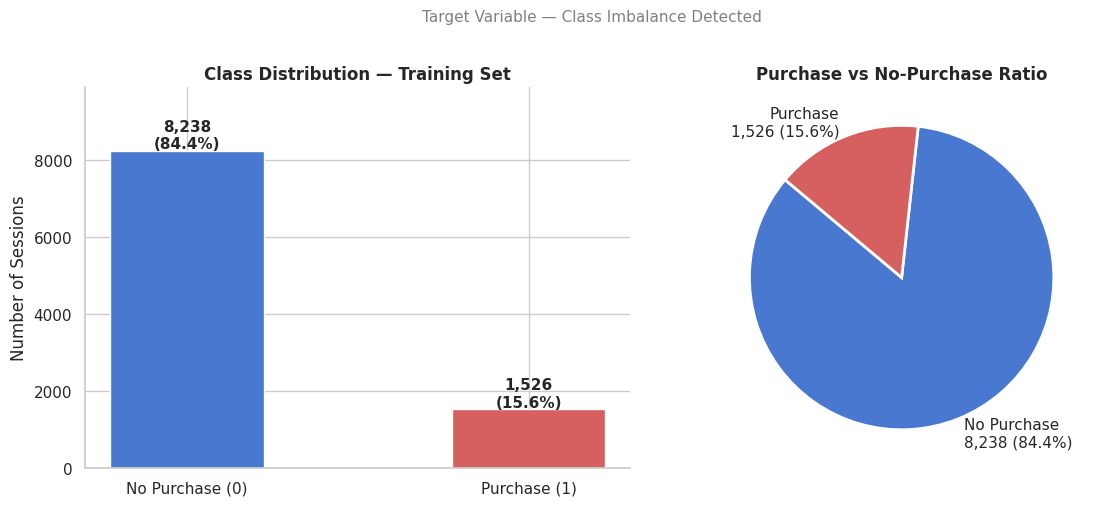

In [ ]:
target_counts = train['Revenue'].value_counts()
total_train   = len(train)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#4878CF', '#D65F5F']

# Bar chart
axes[0].bar(['No Purchase (0)', 'Purchase (1)'],
            target_counts.values, color=colors, width=0.45, edgecolor='white')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 60, f'{v:,}\n({v/total_train*100:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Class Distribution — Training Set', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Sessions')
axes[0].set_ylim(0, max(target_counts.values) * 1.2)

# Pie chart
axes[1].pie(
    target_counts.values,
    labels=[f'No Purchase\n{target_counts[0]:,} ({target_counts[0]/total_train*100:.1f}%)',
            f'Purchase\n{target_counts[1]:,} ({target_counts[1]/total_train*100:.1f}%)'],
    colors=colors, startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Purchase vs No-Purchase Ratio', fontsize=12, fontweight='bold')

plt.suptitle('Target Variable — Class Imbalance Detected', fontsize=11, color='gray', y=1.01)
plt.tight_layout()
plt.show()

### 3.2 Univariate Analysis — Categorical Features

In [ ]:
train['VisitorType'].value_counts()

,count
VisitorType,
Returning_Visitor,8347
New_Visitor,1349
Other,68


In [ ]:
train['Month'].value_counts()

,count
Month,
May,2674
Nov,2358
Mar,1500
Dec,1363
Oct,433
Aug,360
Sep,354
Jul,353
June,225


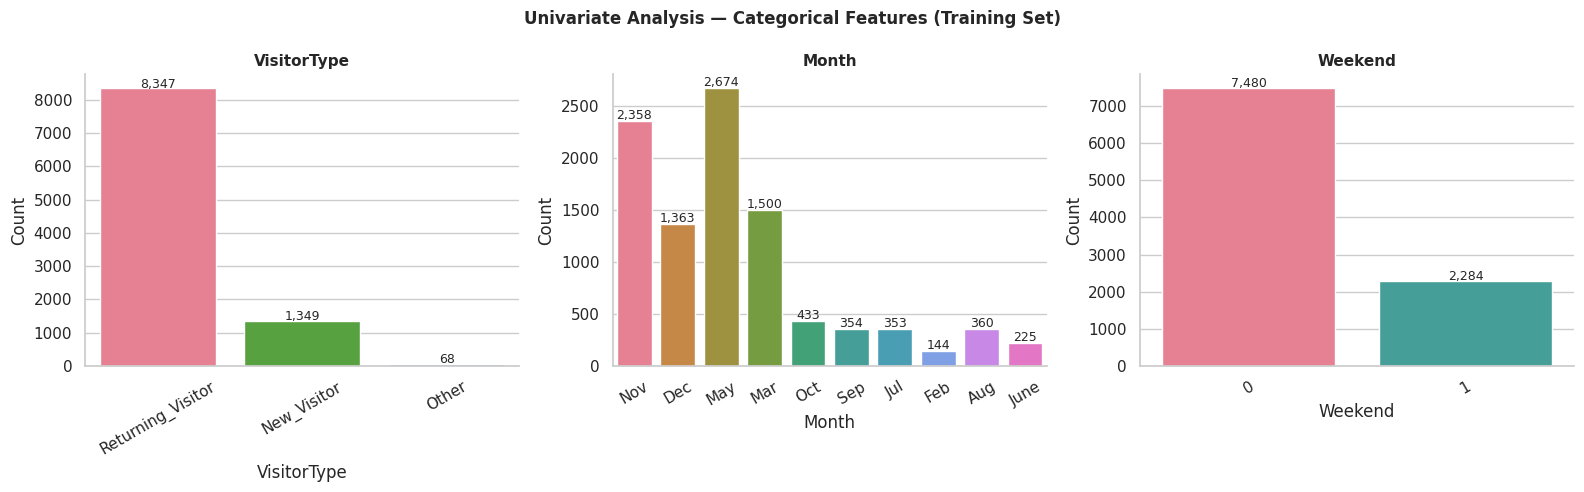

In [ ]:
# Categorical features — count plots
categorical_columns = ['VisitorType', 'Month', 'Weekend']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(categorical_columns):
    sns.countplot(data=train, x=col, palette='husl', ax=axes[i])
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)
    # Add count labels
    for bar in axes[i].patches:
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 20,
            f'{int(bar.get_height()):,}',
            ha='center', fontsize=9
        )

plt.suptitle('Univariate Analysis — Categorical Features (Training Set)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.3 Univariate Analysis — Numeric Features

Examining the distribution of each numeric feature to understand their shape, range, and potential skewness.

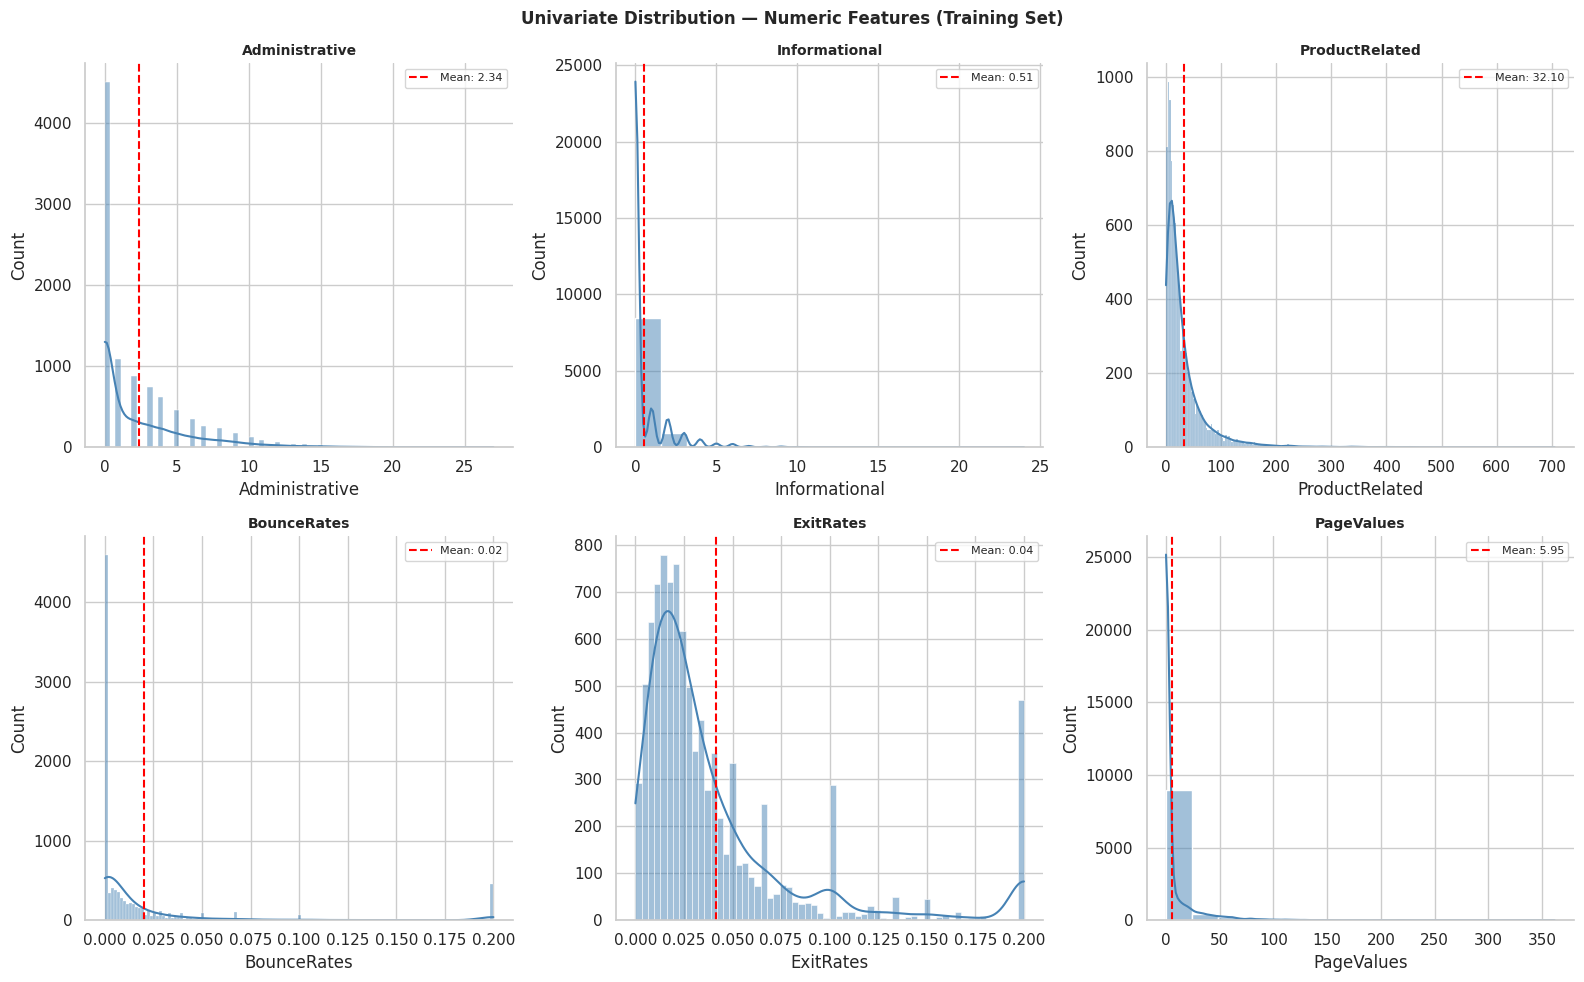

In [ ]:
# Page count features
num_col = ['Administrative', 'Informational', 'ProductRelated',
           'BounceRates', 'ExitRates', 'PageValues']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, col in enumerate(num_col):
    row, col_idx = divmod(i, 3)
    sns.histplot(data=train, x=col, ax=axes[row, col_idx], color='steelblue', kde=True)
    axes[row, col_idx].set_title(col, fontsize=10, fontweight='bold')
    axes[row, col_idx].set_ylabel('Count')
    # Add mean line
    mean_val = train[col].mean()
    axes[row, col_idx].axvline(mean_val, color='red', linestyle='--',
                                linewidth=1.5, label=f'Mean: {mean_val:.2f}')
    axes[row, col_idx].legend(fontsize=8)

plt.suptitle('Univariate Distribution — Numeric Features (Training Set)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

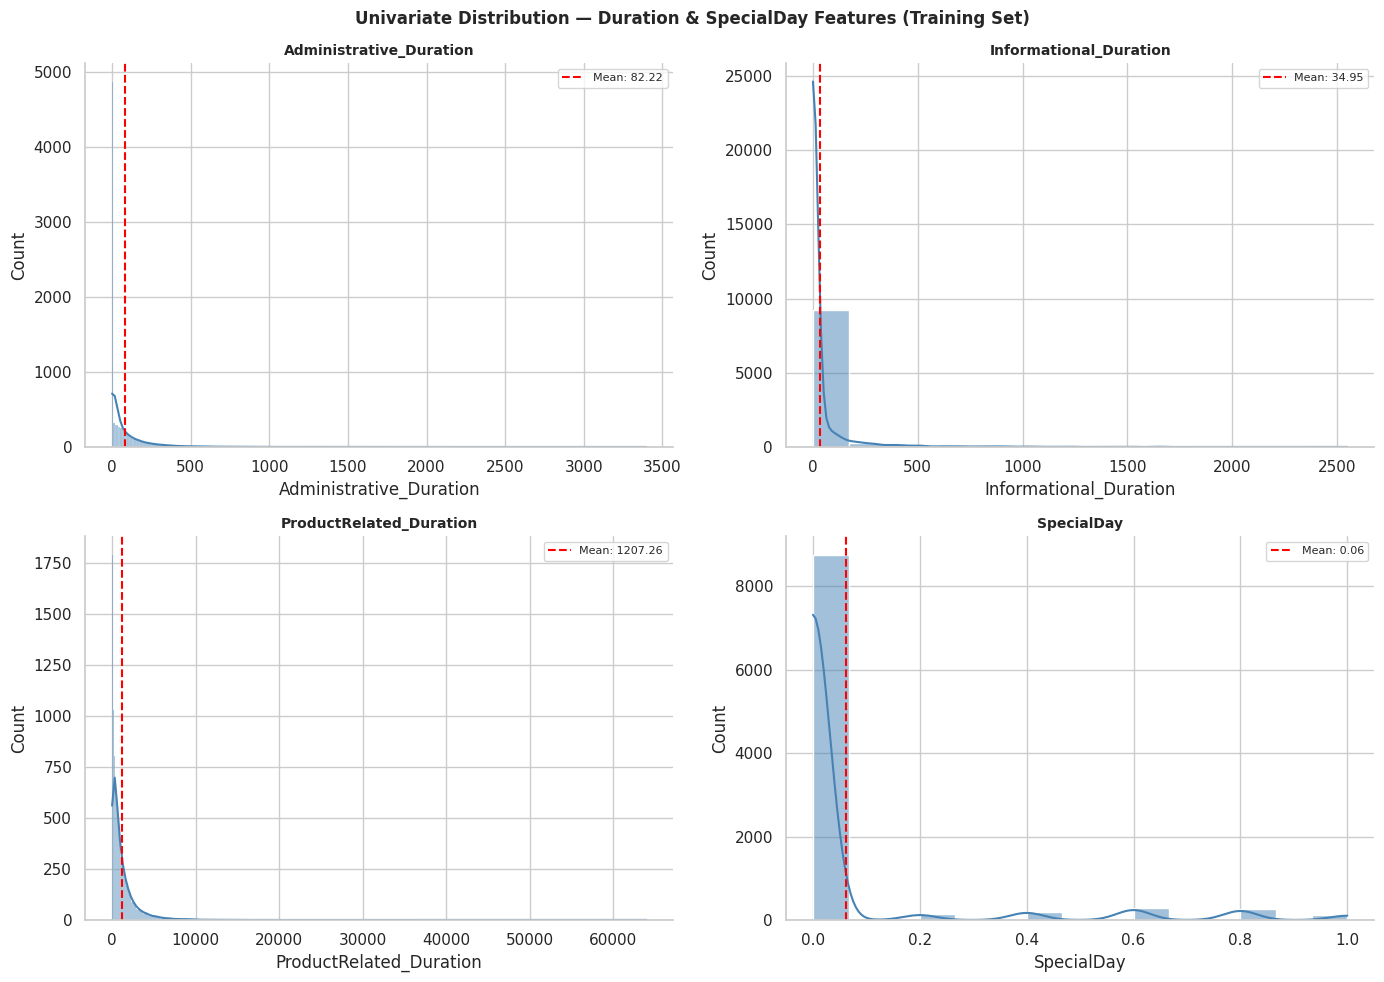

In [ ]:
# Duration features
dur_col = ['Administrative_Duration', 'Informational_Duration',
           'ProductRelated_Duration', 'SpecialDay']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(dur_col):
    row, col_idx = divmod(i, 2)
    sns.histplot(data=train, x=col, ax=axes[row, col_idx], color='steelblue', kde=True)
    axes[row, col_idx].set_title(col, fontsize=10, fontweight='bold')
    axes[row, col_idx].set_ylabel('Count')
    mean_val = train[col].mean()
    axes[row, col_idx].axvline(mean_val, color='red', linestyle='--',
                                linewidth=1.5, label=f'Mean: {mean_val:.2f}')
    axes[row, col_idx].legend(fontsize=8)

plt.suptitle('Univariate Distribution — Duration & SpecialDay Features (Training Set)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

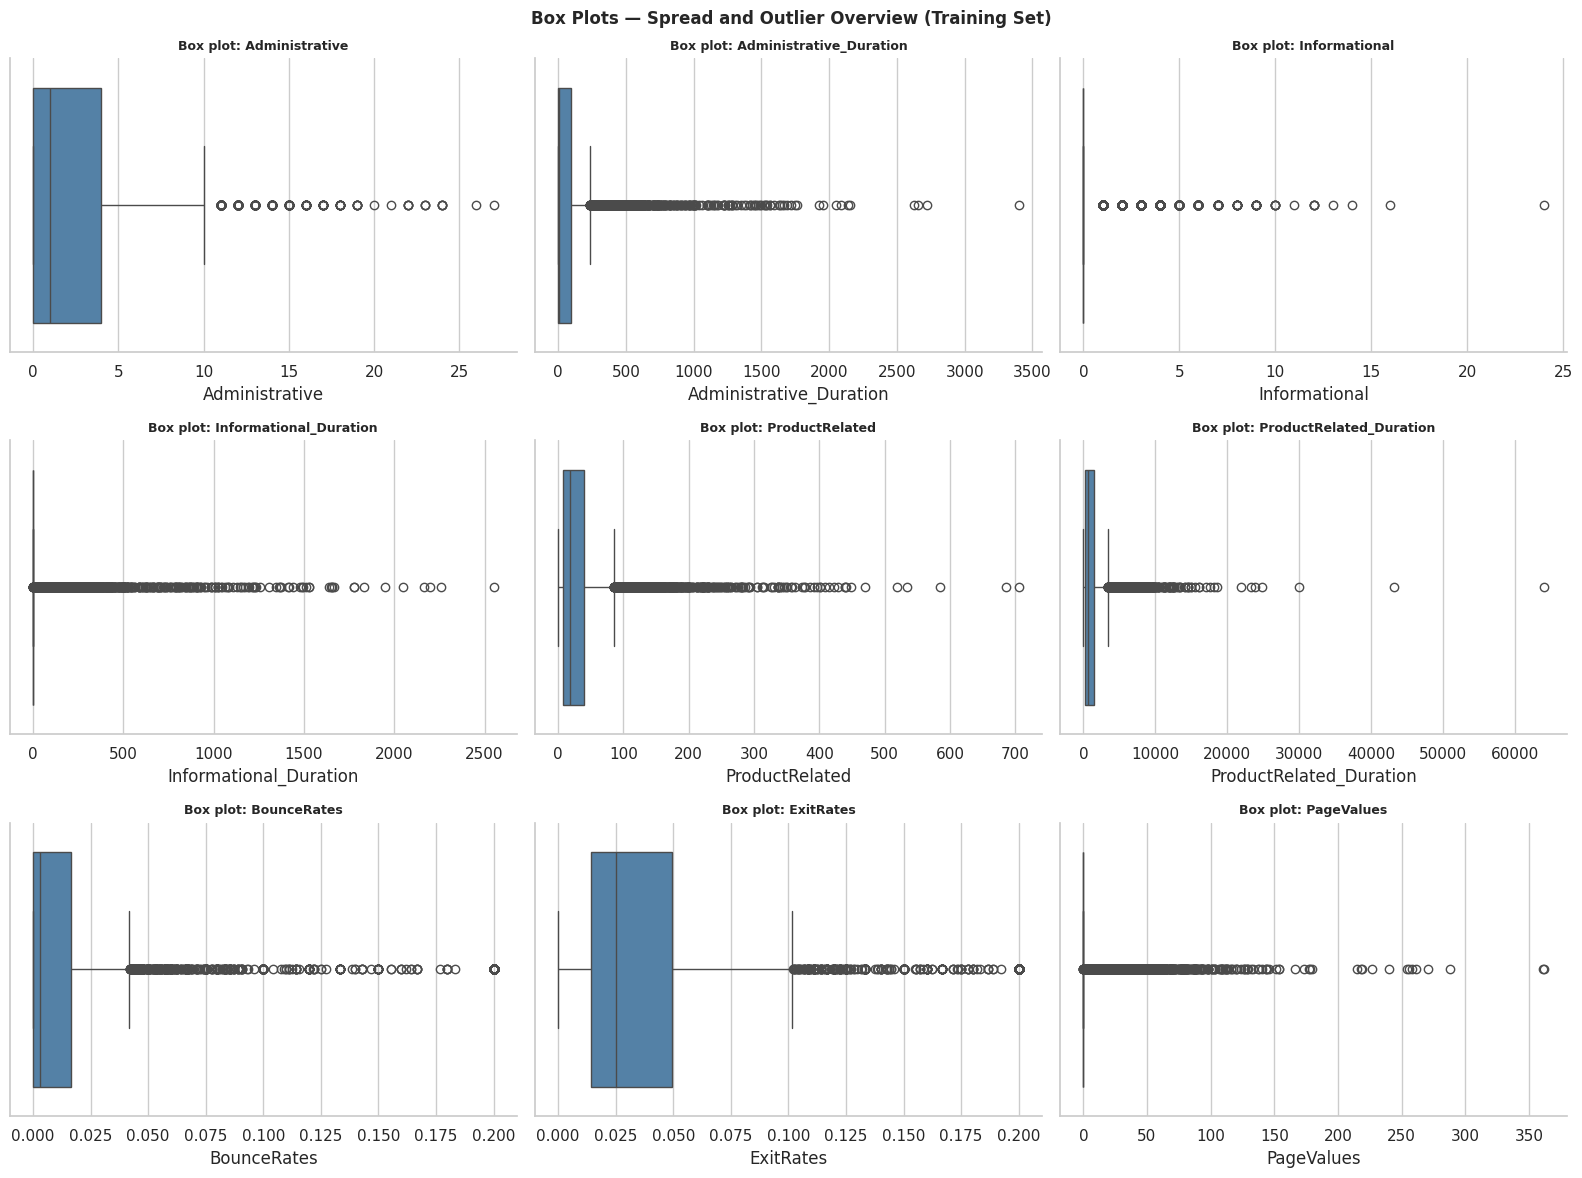

In [ ]:
# Box plots — visualize spread and potential outliers
num_col_all = ['Administrative', 'Administrative_Duration',
               'Informational', 'Informational_Duration',
               'ProductRelated', 'ProductRelated_Duration',
               'BounceRates', 'ExitRates', 'PageValues']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for i, col in enumerate(num_col_all):
    row, col_idx = divmod(i, 3)
    sns.boxplot(data=train, x=col, ax=axes[row, col_idx], color='steelblue')
    axes[row, col_idx].set_title(f'Box plot: {col}', fontsize=9, fontweight='bold')
    axes[row, col_idx].set_xlabel(col)

plt.suptitle('Box Plots — Spread and Outlier Overview (Training Set)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 Bivariate Analysis — Categorical Features vs Revenue

Examining how categorical features relate to the target variable to understand which groups are more likely to purchase.

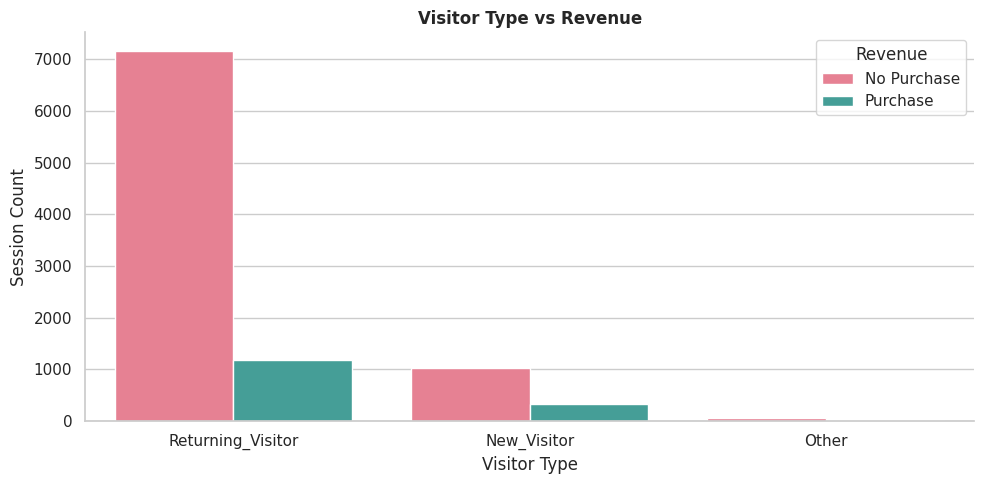

In [ ]:
sns.countplot(data=train, x='VisitorType', hue='Revenue', palette='husl')
plt.title('Visitor Type vs Revenue', fontsize=12, fontweight='bold')
plt.xlabel('Visitor Type')
plt.ylabel('Session Count')
plt.legend(title='Revenue', labels=['No Purchase', 'Purchase'])
plt.tight_layout()
plt.show()

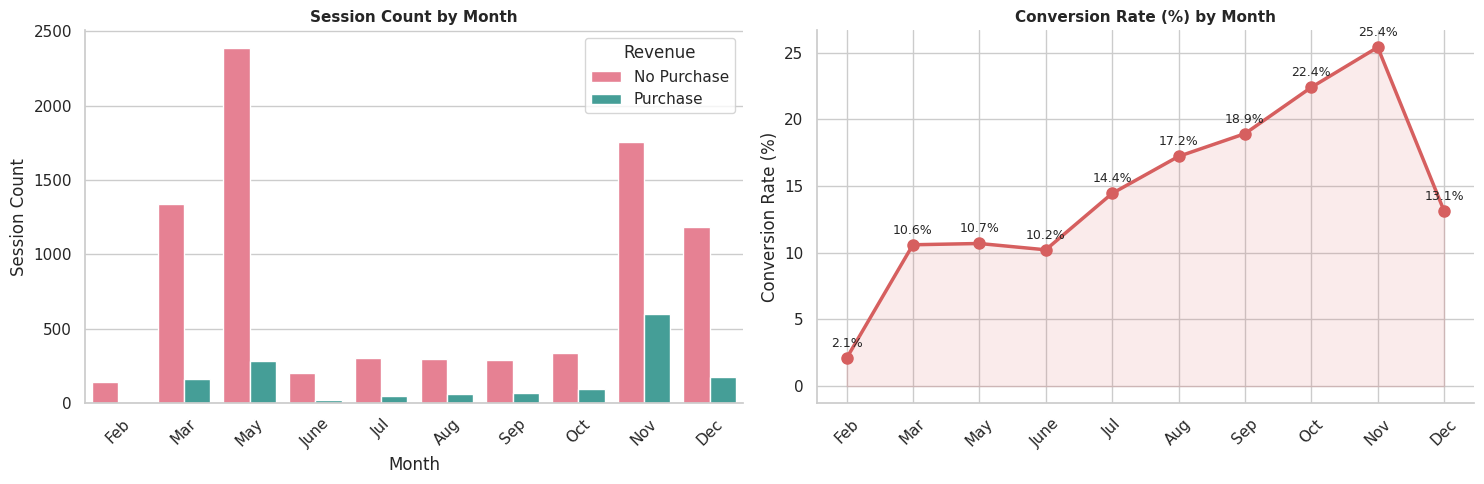

In [ ]:
# Month vs Revenue
month_order = ['Feb','Mar','May','June','Jul','Aug','Sep','Oct','Nov','Dec']
train_month = train.copy()
train_month['Month'] = pd.Categorical(train_month['Month'], categories=month_order, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(data=train_month, x='Month', hue='Revenue', palette='husl', ax=axes[0])
axes[0].set_title('Session Count by Month', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Session Count')
axes[0].legend(title='Revenue', labels=['No Purchase', 'Purchase'])
axes[0].tick_params(axis='x', rotation=45)

# Conversion rate by month
month_conv = train.groupby('Month')['Revenue'].agg(['mean','count']).reset_index()
month_conv.columns = ['Month','ConvRate','Sessions']
month_conv['ConvRate'] *= 100
month_conv['Month'] = pd.Categorical(month_conv['Month'], categories=month_order, ordered=True)
month_conv = month_conv.sort_values('Month')

x = range(len(month_conv))
axes[1].plot(x, month_conv['ConvRate'], marker='o', color='#D65F5F',
             linewidth=2.5, markersize=8)
axes[1].fill_between(x, month_conv['ConvRate'], alpha=0.12, color='#D65F5F')
for xi, yi in zip(x, month_conv['ConvRate']):
    axes[1].annotate(f'{yi:.1f}%', (xi, yi),
                     textcoords='offset points', xytext=(0, 8),
                     ha='center', fontsize=9)
axes[1].set_xticks(x)
axes[1].set_xticklabels(month_conv['Month'], rotation=45)
axes[1].set_title('Conversion Rate (%) by Month', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Conversion Rate (%)')

plt.tight_layout()
plt.show()

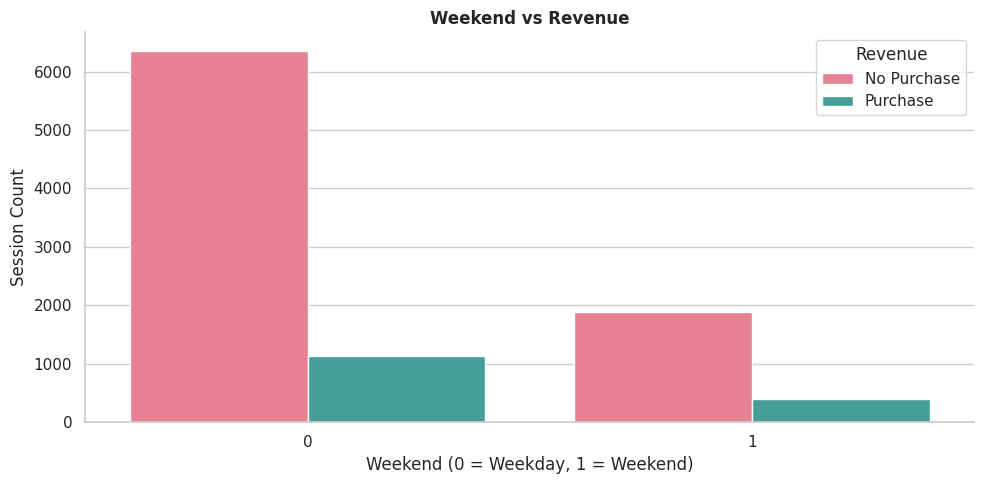

In [ ]:
# Weekend vs Revenue
sns.countplot(data=train, x='Weekend', hue='Revenue', palette='husl')
plt.title('Weekend vs Revenue', fontsize=12, fontweight='bold')
plt.xlabel('Weekend (0 = Weekday, 1 = Weekend)')
plt.ylabel('Session Count')
plt.legend(title='Revenue', labels=['No Purchase', 'Purchase'])
plt.tight_layout()
plt.show()

### 3.5 Bivariate Analysis — Numeric Features vs Revenue

Comparing the distribution of key numeric features between buyers and non-buyers.

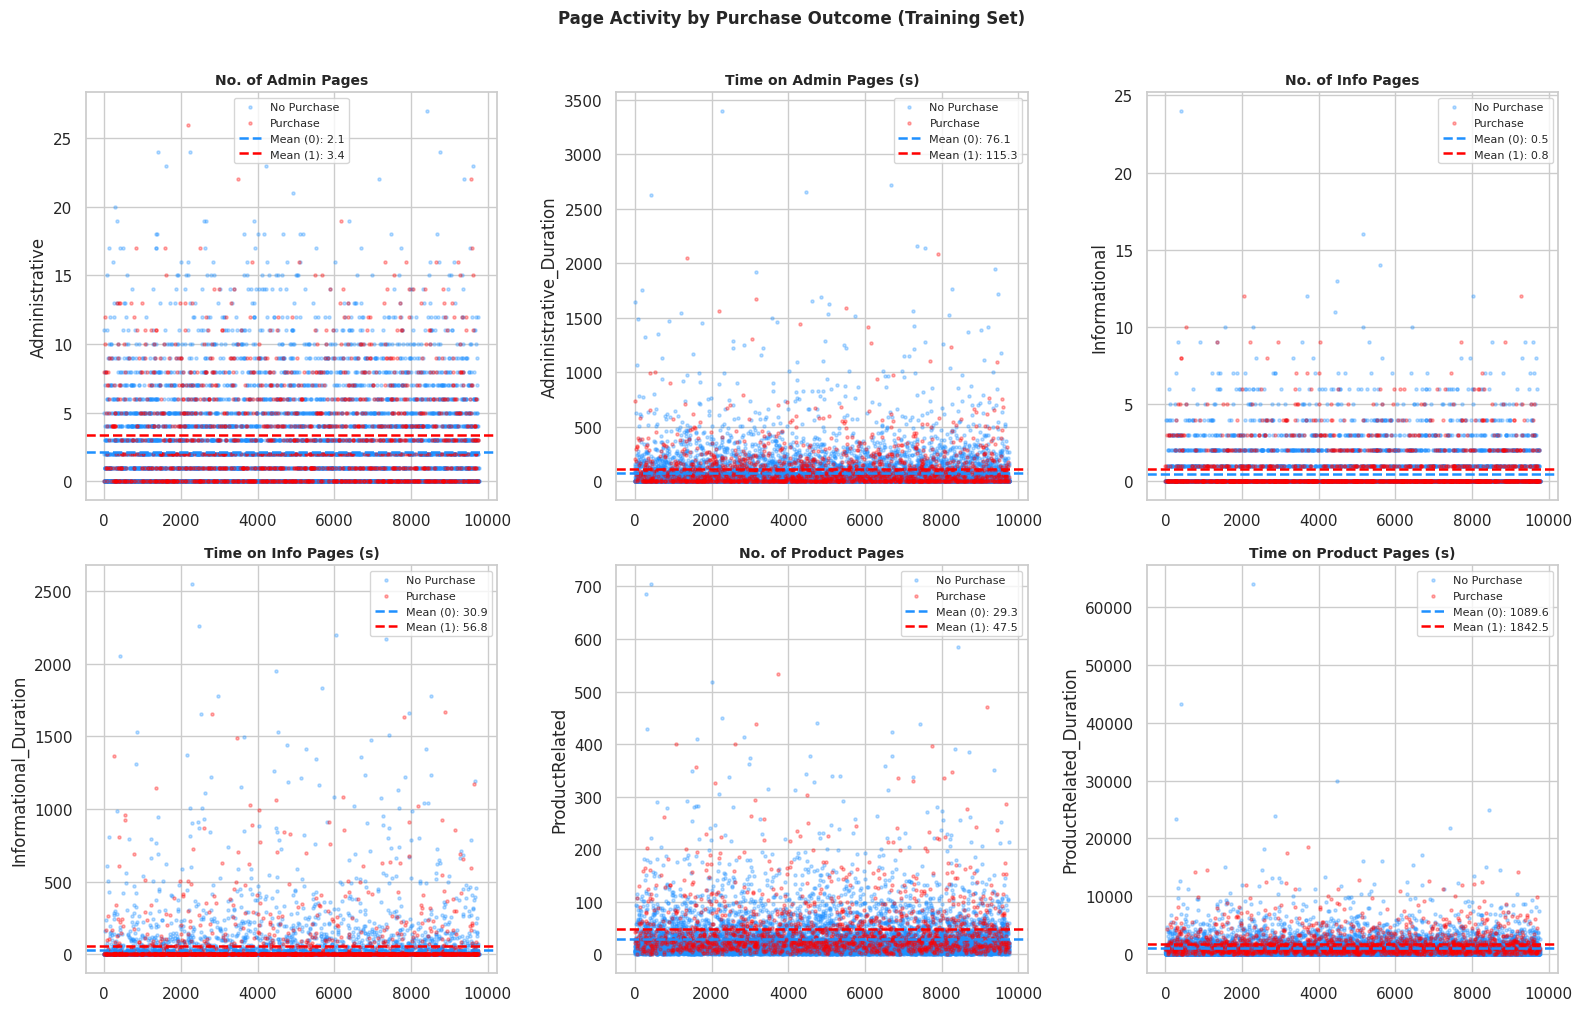

In [ ]:
# Page count and duration features vs Revenue
sns.set(style='whitegrid')

no_purchase = train[train['Revenue'] == 0]
purchase    = train[train['Revenue'] == 1]

page_features = [
    ('Administrative',          'No. of Admin Pages'),
    ('Administrative_Duration', 'Time on Admin Pages (s)'),
    ('Informational',           'No. of Info Pages'),
    ('Informational_Duration',  'Time on Info Pages (s)'),
    ('ProductRelated',          'No. of Product Pages'),
    ('ProductRelated_Duration', 'Time on Product Pages (s)'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (col, label) in enumerate(page_features):
    mean_no  = no_purchase[col].mean()
    mean_yes = purchase[col].mean()

    axes[i].scatter(no_purchase.index, no_purchase[col],
                    color='DodgerBlue', s=5, alpha=0.3, label='No Purchase')
    axes[i].scatter(purchase.index, purchase[col],
                    color='red', s=5, alpha=0.3, label='Purchase')
    axes[i].axhline(mean_no,  color='DodgerBlue', linestyle='--',
                    linewidth=1.8, label=f'Mean (0): {mean_no:.1f}')
    axes[i].axhline(mean_yes, color='red', linestyle='--',
                    linewidth=1.8, label=f'Mean (1): {mean_yes:.1f}')
    axes[i].set_title(label, fontsize=10, fontweight='bold')
    axes[i].set_ylabel(col)
    axes[i].legend(fontsize=8)

plt.suptitle('Page Activity by Purchase Outcome (Training Set)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

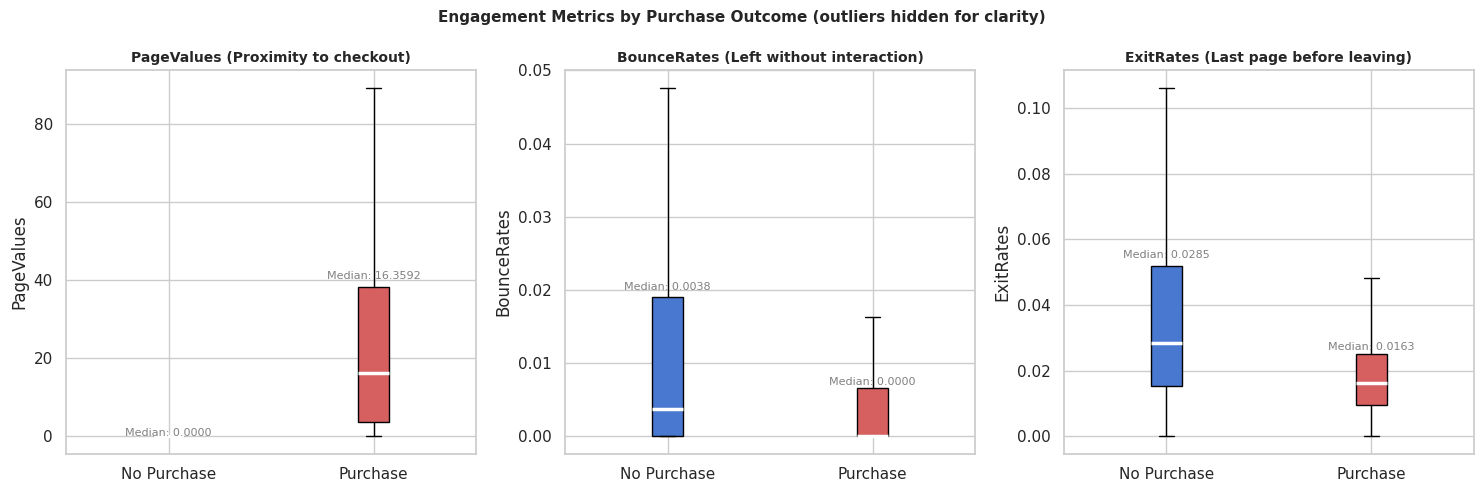

=== MEAN COMPARISON: Buyers vs Non-Buyers ===
  PageValues           No Purchase: 1.9836  |  Purchase: 27.3342  |  Δ = +1278.0%
  BounceRates          No Purchase: 0.0231  |  Purchase: 0.0052  |  Δ = -77.7%
  ExitRates            No Purchase: 0.0455  |  Purchase: 0.0195  |  Δ = -57.1%


In [ ]:
# Engagement metrics vs Revenue — box plots
engagement_features = [
    ('PageValues',  'PageValues (Proximity to checkout)'),
    ('BounceRates', 'BounceRates (Left without interaction)'),
    ('ExitRates',   'ExitRates (Last page before leaving)'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (col, label) in enumerate(engagement_features):
    no_buy = train[train['Revenue'] == 0][col]
    buy    = train[train['Revenue'] == 1][col]

    bp = axes[i].boxplot(
        [no_buy, buy],
        labels=['No Purchase', 'Purchase'],
        patch_artist=True, showfliers=False,
        medianprops={'color': 'white', 'linewidth': 2.5}
    )
    bp['boxes'][0].set_facecolor('#4878CF')
    bp['boxes'][1].set_facecolor('#D65F5F')

    axes[i].set_title(label, fontsize=10, fontweight='bold')
    axes[i].set_ylabel(col)

    for j, data in enumerate([no_buy, buy]):
        axes[i].text(j+1, data.quantile(0.75)*1.05,
                     f'Median: {data.median():.4f}',
                     ha='center', fontsize=8, color='gray')

plt.suptitle('Engagement Metrics by Purchase Outcome (outliers hidden for clarity)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print('=== MEAN COMPARISON: Buyers vs Non-Buyers ===')
for col, _ in engagement_features:
    m0  = train[train['Revenue']==0][col].mean()
    m1  = train[train['Revenue']==1][col].mean()
    pct = (m1-m0)/max(abs(m0), 1e-9)*100
    print(f'  {col:<20} No Purchase: {m0:.4f}  |  Purchase: {m1:.4f}  |  Δ = {pct:+.1f}%')

### 3.6 Correlation Analysis

The correlation heatmap identifies which numeric features correlate most with `Revenue` and reveals multicollinearity between features — relevant for Logistic Regression.

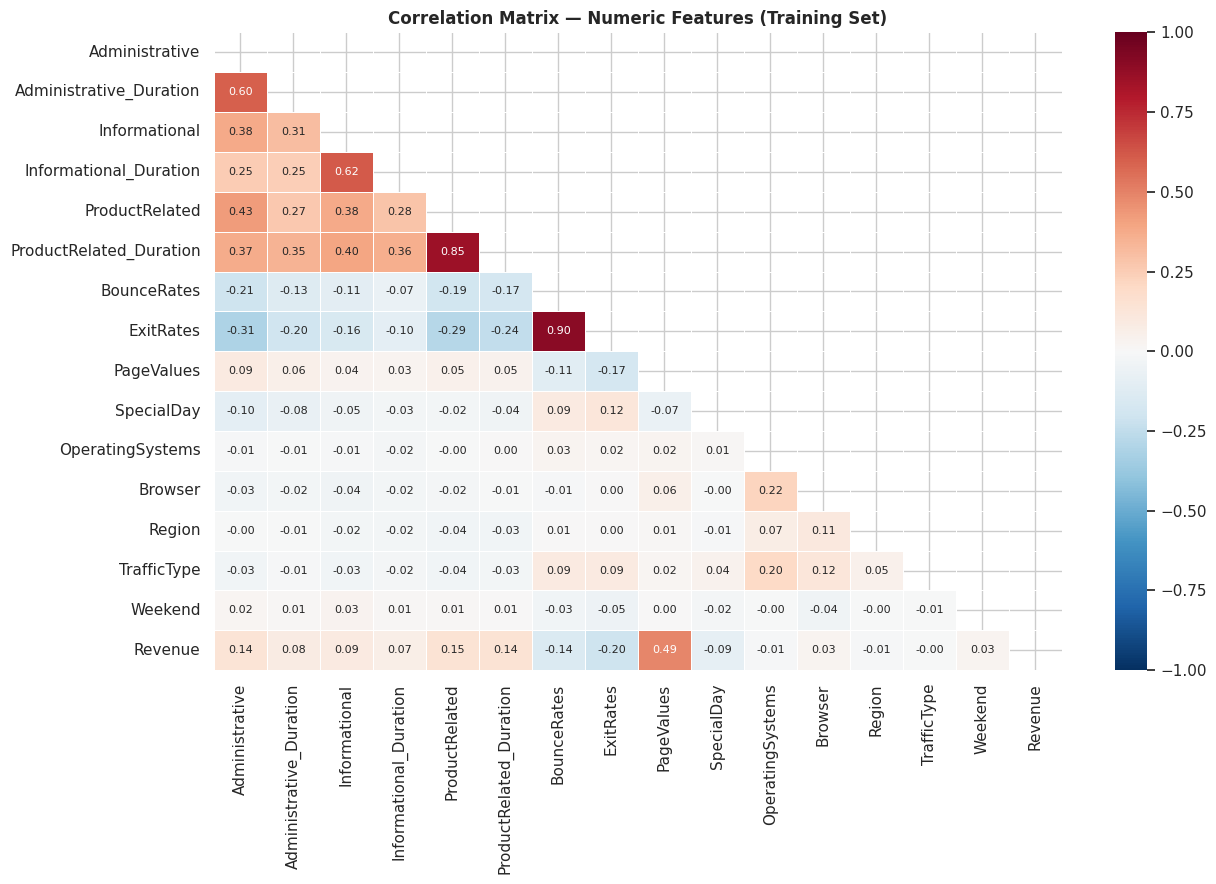

Top feature correlations with Revenue:
  PageValues                          +0.4881  ████████████
  ExitRates                           -0.2046  █████
  ProductRelated                      +0.1477  ███
  BounceRates                         -0.1441  ███
  ProductRelated_Duration             +0.1419  ███
  Administrative                      +0.1351  ███
  SpecialDay                          -0.0865  ██
  Informational                       +0.0865  ██
  Administrative_Duration             +0.0793  █
  Informational_Duration              +0.0653  █


In [ ]:
num_train = train.select_dtypes(include=[np.number])
corr_matrix = num_train.corr()

plt.figure(figsize=(13, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, annot_kws={'size': 8}
)
plt.title('Correlation Matrix — Numeric Features (Training Set)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with Revenue
corr_rev = corr_matrix['Revenue'].drop('Revenue').sort_values(key=abs, ascending=False)
print('Top feature correlations with Revenue:')
for feat, val in corr_rev.head(10).items():
    bar = '█' * int(abs(val) * 25)
    print(f'  {feat:<35} {val:+.4f}  {bar}')

---
## Section 4 — Outlier Analysis


In [ ]:
# Check the scale of outliers per feature using IQR rule
outlier_cols = [
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'PageValues'
]

print('=== OUTLIER ANALYSIS (IQR rule, threshold = 1.5) ===')
print(f'{"Feature":<35} {"Outlier count":>15} {"% of train":>12}')
print('-' * 65)
total_flagged = set()
for col in outlier_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    mask = (train[col] < Q1 - 1.5*IQR) | (train[col] > Q3 + 1.5*IQR)
    n_outliers = mask.sum()
    pct = n_outliers / len(train) * 100
    print(f'{col:<35} {n_outliers:>15,} {pct:>11.1f}%')
    total_flagged.update(train.index[mask].tolist())

print('-' * 65)
print(f'{"Unique rows flagged (any column)":<35} {len(total_flagged):>15,} {len(total_flagged)/len(train)*100:>11.1f}%')
print()
print('=> Removing all flagged rows would discard ~51% of training data.')
print('=> Decision: retain all observations. Robust preprocessing handles outlier sensitivity.')

=== OUTLIER ANALYSIS (IQR rule, threshold = 1.5) ===
Feature                               Outlier count   % of train
-----------------------------------------------------------------
Administrative                                  325         3.3%
Administrative_Duration                         937         9.6%
Informational                                 2,107        21.6%
Informational_Duration                        1,917        19.6%
ProductRelated                                  767         7.9%
ProductRelated_Duration                         751         7.7%
BounceRates                                   1,127        11.5%
ExitRates                                       780         8.0%
PageValues                                    2,187        22.4%
-----------------------------------------------------------------
Unique rows flagged (any column)              5,041        51.6%

=> Removing all flagged rows would discard ~55% of training data.
=> Decision: retain all observati

In [ ]:
# Skewness check — quantifies extreme value presence
print('=== SKEWNESS OF NUMERIC FEATURES (Training Set) ===')
skew = train[outlier_cols].skew().sort_values(ascending=False)
for col, val in skew.items():
    level = 'HIGH ⚠' if abs(val) > 2 else ('Moderate' if abs(val) > 1 else 'Low')
    print(f'  {col:<35} skew = {val:+.2f}  → {level}')

print()
print('Note: High skewness is expected in web session data — a small number of')
print('      highly engaged users create long tails. StandardScaler normalizes')
print('      these ranges before feeding into LR and KNN.')

=== SKEWNESS OF NUMERIC FEATURES (Training Set) ===
  ProductRelated_Duration             skew = +7.87  → HIGH ⚠
  Informational_Duration              skew = +7.54  → HIGH ⚠
  PageValues                          skew = +6.55  → HIGH ⚠
  Administrative_Duration             skew = +5.68  → HIGH ⚠
  ProductRelated                      skew = +4.39  → HIGH ⚠
  Informational                       skew = +4.10  → HIGH ⚠
  BounceRates                         skew = +3.17  → HIGH ⚠
  ExitRates                           skew = +2.24  → HIGH ⚠
  Administrative                      skew = +1.99  → Moderate

Note: High skewness is expected in web session data — a small number of
      highly engaged users create long tails. StandardScaler normalizes
      these ranges before feeding into LR and KNN.


In [ ]:
# Descriptive statistics summary
train[outlier_cols].describe().round(3)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues
count,9764.000,9764.000,9764.000,9764.000,9764.000,9764.000,9764.000,9764.000,9764.000
mean,2.343,82.220,0.510,34.951,32.102,1207.265,0.020,0.041,5.946
std,3.349,179.502,1.283,143.828,44.817,1926.389,0.045,0.046,18.860
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.000,0.000,0.000,0.000,8.000,193.467,0.000,0.014,0.000
50%,1.000,9.000,0.000,0.000,18.000,617.000,0.003,0.025,0.000
75%,4.000,94.725,0.000,0.000,39.000,1483.650,0.017,0.049,0.000
max,27.000,3398.750,24.000,2549.375,705.000,63973.522,0.200,0.200,361.764


---
## Section 5 — Data Transformation

All transformations are **fit on the training set only** and then applied to the test set.  
This ensures no information from the test set leaks into the preprocessing pipeline.

Steps:
1. **Category Encoding** — One-Hot Encoding for `VisitorType`, ordinal mapping for `Month`
2. **Separate X and y** arrays
3. **Feature Scaling** — StandardScaler (fit on train only)

### 5.1 Category Encoding

- **VisitorType** → One-Hot Encoding: no natural ordering between visitor types
- **Month** → Ordinal encoding (Jan=1 to Dec=12): preserves temporal ordering

In [ ]:
one_hot_encoder = OneHotEncoder(drop='first', sparse_output=False)

In [ ]:
# Categorical columns to transform
cat_cols = ['VisitorType']

# Fit encoder on training set
cat_vals = train[cat_cols]
cat_vals

,VisitorType
0,Returning_Visitor
1,New_Visitor
2,Returning_Visitor
3,New_Visitor
4,Returning_Visitor
...,...
9759,Returning_Visitor
9760,Returning_Visitor
9761,Returning_Visitor
9762,Returning_Visitor


In [ ]:
# Fit and transform training set
transformed = one_hot_encoder.fit_transform(cat_vals)
transformed

array([[0., 1.],
       [0., 0.],
       [0., 1.],
       ...,
       [0., 1.],
       [0., 1.],
       [0., 1.]])

In [ ]:
# New column names from encoder
new_col_names = one_hot_encoder.get_feature_names_out(cat_cols)
new_col_names

array(['VisitorType_Other', 'VisitorType_Returning_Visitor'], dtype=object)

In [ ]:
# Add encoded columns to training set and drop original
for i, new_col_name in enumerate(new_col_names):
    train[new_col_name] = transformed[:, i]

train = train.drop(cat_cols, axis=1)
train.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,Weekend,Revenue,VisitorType_Other,VisitorType_Returning_Visitor
0,8,203.6,1,0.0,42,1052.400000,0.0,0.004545,37.357258,0.0,Nov,2,2,5,2,0,1,0.0,1.0
1,0,0.0,0,0.0,30,901.288889,0.0,0.007333,34.148420,0.0,Dec,2,2,7,2,0,1,0.0,0.0
2,0,0.0,0,0.0,13,421.166667,0.0,0.028205,0.000000,0.8,May,1,1,1,2,0,0,0.0,1.0
3,2,40.0,0,0.0,5,558.500000,0.0,0.028571,0.000000,0.0,Mar,2,2,7,2,1,0,0.0,0.0
4,0,0.0,0,0.0,16,1599.266667,0.0,0.013333,0.000000,0.0,May,4,2,2,13,0,0,0.0,1.0


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9764 entries, 0 to 9763
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 9764 non-null   int64  
 1   Administrative_Duration        9764 non-null   float64
 2   Informational                  9764 non-null   int64  
 3   Informational_Duration         9764 non-null   float64
 4   ProductRelated                 9764 non-null   int64  
 5   ProductRelated_Duration        9764 non-null   float64
 6   BounceRates                    9764 non-null   float64
 7   ExitRates                      9764 non-null   float64
 8   PageValues                     9764 non-null   float64
 9   SpecialDay                     9764 non-null   float64
 10  Month                          9764 non-null   object 
 11  OperatingSystems               9764 non-null   int64  
 12  Browser                        9764 non-null   i

In [ ]:
# Transform test set using encoder fitted on training set (transform only — no fit)
cat_vals_test    = test[cat_cols]
transformed_test = one_hot_encoder.transform(cat_vals_test)

for i, new_col_name in enumerate(new_col_names):
    test[new_col_name] = transformed_test[:, i]

test = test.drop(cat_cols, axis=1)
test.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,Weekend,Revenue,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.000000,0,0.0,12,482.500000,0.02,0.040000,0.0,0.0,Nov,1,2,1,10,0,0,0.0,1.0
1,2,287.200000,0,0.0,16,473.283333,0.00,0.002222,0.0,0.0,Oct,2,2,1,2,1,0,0.0,0.0
2,2,187.900000,4,100.1,29,2107.033333,0.00,0.024242,0.0,0.0,Oct,1,1,3,1,0,0,0.0,1.0
3,7,280.266667,0,0.0,11,329.683333,0.00,0.023077,0.0,0.0,Dec,2,2,7,2,0,0,0.0,1.0
4,0,0.000000,0,0.0,5,0.000000,0.20,0.200000,0.0,0.0,May,3,2,5,6,0,0,0.0,1.0


In [ ]:
# Month: ordinal encoding — fit mapping from training set
month_mapping = {
    'Jan': 1, 'Feb': 2,  'Mar': 3,  'Apr': 4,
    'May': 5, 'June': 6, 'Jul': 7,  'Aug': 8,
    'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}

train['Month'] = train['Month'].replace(month_mapping)
test['Month']  = test['Month'].replace(month_mapping)

train.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,Weekend,Revenue,VisitorType_Other,VisitorType_Returning_Visitor
0,8,203.6,1,0.0,42,1052.400000,0.0,0.004545,37.357258,0.0,11,2,2,5,2,0,1,0.0,1.0
1,0,0.0,0,0.0,30,901.288889,0.0,0.007333,34.148420,0.0,12,2,2,7,2,0,1,0.0,0.0
2,0,0.0,0,0.0,13,421.166667,0.0,0.028205,0.000000,0.8,5,1,1,1,2,0,0,0.0,1.0
3,2,40.0,0,0.0,5,558.500000,0.0,0.028571,0.000000,0.0,3,2,2,7,2,1,0,0.0,0.0
4,0,0.0,0,0.0,16,1599.266667,0.0,0.013333,0.000000,0.0,5,4,2,2,13,0,0,0.0,1.0


In [ ]:
# Separate target and predictors
ytrain = train['Revenue'].copy()
Xtrain = train.drop('Revenue', axis=1)
ytest  = test['Revenue'].copy()
Xtest  = test.drop('Revenue', axis=1)

Xtrain.shape, ytrain.shape, Xtest.shape, ytest.shape

((9764, 18), (9764,), (2441, 18), (2441,))

In [ ]:
Xtrain.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,Weekend,VisitorType_Other,VisitorType_Returning_Visitor
0,8,203.6,1,0.0,42,1052.400000,0.0,0.004545,37.357258,0.0,11,2,2,5,2,0,0.0,1.0
1,0,0.0,0,0.0,30,901.288889,0.0,0.007333,34.148420,0.0,12,2,2,7,2,0,0.0,0.0
2,0,0.0,0,0.0,13,421.166667,0.0,0.028205,0.000000,0.8,5,1,1,1,2,0,0.0,1.0
3,2,40.0,0,0.0,5,558.500000,0.0,0.028571,0.000000,0.0,3,2,2,7,2,1,0.0,0.0
4,0,0.0,0,0.0,16,1599.266667,0.0,0.013333,0.000000,0.0,5,4,2,2,13,0,0.0,1.0


### 5.2 Feature Scaling

**Why scale?**
- **Logistic Regression**: uses optimization-based learning — features with large numeric ranges can dominate the model.
- **KNN**: uses Euclidean distance — a feature with a range of 0–50,000 will overwhelm one with a range of 0–1.
- **MLP Neural Network**: uses backpropagation and gradient-based optimization, so it is sensitive to feature scales.
- **Random Forest**: does **NOT** need scaling — tree splits are based on relative thresholds, not absolute distances.

**Rule:** `StandardScaler` is **fit on training data only**, then applied to both sets.  
Fitting on test data would leak the test distribution into preprocessing — a form of data leakage.

In [ ]:
numeric_features = [
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'PageValues',
    'SpecialDay', 'Month'
]

X_train_scaled = Xtrain.copy()
X_test_scaled  = Xtest.copy()

# Initialize scaler
scaler = StandardScaler()

# Fit on training set only, then transform both
X_train_scaled[numeric_features] = scaler.fit_transform(Xtrain[numeric_features])
X_test_scaled[numeric_features]  = scaler.transform(Xtest[numeric_features])

In [ ]:
X_train_scaled.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,Weekend,VisitorType_Other,VisitorType_Returning_Visitor
0,1.689206,0.676238,0.381750,-0.243015,0.220868,-0.080395,-0.448703,-0.800192,1.665596,-0.311837,0.990316,2,2,5,2,0,0.0,1.0
1,-0.699498,-0.458067,-0.397879,-0.243015,-0.046900,-0.158842,-0.448703,-0.739774,1.495448,-0.311837,1.285702,2,2,7,2,0,0.0,0.0
2,-0.699498,-0.458067,-0.397879,-0.243015,-0.426237,-0.408089,-0.448703,-0.287446,-0.315264,3.689185,-0.781997,1,1,1,2,0,0.0,1.0
3,-0.102322,-0.235218,-0.397879,-0.243015,-0.604748,-0.336795,-0.448703,-0.279507,-0.315264,-0.311837,-1.372768,2,2,7,2,1,0.0,0.0
4,-0.699498,-0.458067,-0.397879,-0.243015,-0.359295,0.203501,-0.448703,-0.609743,-0.315264,-0.311837,-0.781997,4,2,2,13,0,0.0,1.0


In [ ]:
X_test_scaled.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,Weekend,VisitorType_Other,VisitorType_Returning_Visitor
0,-0.699498,-0.458067,-0.397879,-0.243015,-0.448551,-0.376249,-0.006534,-0.031831,-0.315264,-0.311837,0.990316,1,2,1,10,0,0.0,1.0
1,-0.102322,1.141994,-0.397879,-0.243015,-0.359295,-0.381034,-0.448703,-0.850540,-0.315264,-0.311837,0.694931,2,2,1,2,1,0.0,0.0
2,-0.102322,0.588769,2.720635,0.452989,-0.069213,0.467099,-0.448703,-0.373324,-0.315264,-0.311837,0.694931,1,1,3,1,0,0.0,1.0
3,1.390618,1.103366,-0.397879,-0.243015,-0.470865,-0.455581,-0.448703,-0.398583,-0.315264,-0.311837,1.285702,2,2,7,2,0,0.0,1.0
4,-0.699498,-0.458067,-0.397879,-0.243015,-0.604748,-0.626730,3.972987,3.435644,-0.315264,-0.311837,-0.781997,3,2,5,6,0,0.0,1.0


In [ ]:
print('Preprocessing summary:')
print(f'  Xtrain shape:  {Xtrain.shape}  (used for RF)')
print(f'  X_train_scaled shape: {X_train_scaled.shape}  (used for LR and KNN)')
print(f'  ytrain purchase rate: {ytrain.mean()*100:.1f}%')
print()
print(f'  Train mean after scaling: {X_train_scaled[numeric_features].values.mean():.6f} (≈ 0)')
print(f'  Train std after scaling:  {X_train_scaled[numeric_features].values.std():.6f}  (≈ 1)')

Preprocessing summary:
  Xtrain shape:  (9764, 18)  (used for RF)
  X_train_scaled shape: (9764, 18)  (used for LR and KNN)
  ytrain purchase rate: 15.6%

  Train mean after scaling: -0.000000 (≈ 0)
  Train std after scaling:  1.000000  (≈ 1)


In [ ]:
# MLP readiness check
print('=== MLP READINESS CHECK ===')

print(f'X_train_scaled shape: {X_train_scaled.shape}')
print(f'X_test_scaled shape : {X_test_scaled.shape}')
print(f'ytrain shape        : {ytrain.shape}')
print(f'ytest shape         : {ytest.shape}')

print('\nMissing values:')
print(f'  X_train_scaled: {X_train_scaled.isna().sum().sum()}')
print(f'  X_test_scaled : {X_test_scaled.isna().sum().sum()}')

print('\nNon-numeric columns in X_train_scaled:')
non_numeric_cols = X_train_scaled.select_dtypes(exclude=[np.number]).columns.tolist()
print(non_numeric_cols if len(non_numeric_cols) > 0 else 'No non-numeric columns found.')

print('\nTarget distribution:')
print(ytrain.value_counts(normalize=True).mul(100).round(2))

=== MLP READINESS CHECK ===
X_train_scaled shape: (9764, 18)
X_test_scaled shape : (2441, 18)
ytrain shape        : (9764,)
ytest shape         : (2441,)

Missing values:
  X_train_scaled: 0
  X_test_scaled : 0

Non-numeric columns in X_train_scaled:
No non-numeric columns found.

Target distribution:
Revenue
0    84.37
1    15.63
Name: proportion, dtype: float64


---
## Section 6 — Model Development

We use **10-fold cross-validation on the training set** to compare four models before selecting the best one.  
The test set remains locked throughout this section.

The added model is **MLP Neural Network**, which represents the deep learning approach in this project. It is included to evaluate whether a neural network can improve classification performance on the online shoppers dataset.
### Models and Configuration

| Model | Input Data | Imbalance Handling | Lecture Reference |
|---|---|---|---|
| Logistic Regression | Scaled | `class_weight='balanced'` | Lecture 4 |
| KNN | Scaled | Large K reduces noise but may still suffer from imbalance | Lecture 4 |
| Random Forest | Raw (unscaled) | `class_weight='balanced'` | Lecture 4 |
| MLP Neural Network | Scaled | No built-in `class_weight`; evaluated through F1-Macro | Lecture 7 |

In [ ]:
# Helper function to evaluate a trained model on any dataset
def evaluate_model(model, ytest, Xtest):
    yhat = model.predict(Xtest)
    print(classification_report(ytest, yhat, zero_division=0))

### Logistic Regression


In [ ]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',  # compensates for 15.5% / 84.5% imbalance
    random_state=42
)
lr_fscore = cross_val_score(lr, X_train_scaled, ytrain, scoring='f1_macro', cv=10)

In [ ]:
lr_fscore

array([0.77622227, 0.77699313, 0.76029097, 0.80020558, 0.73997287,
       0.76414933, 0.77206247, 0.80944117, 0.77325336, 0.79223897])

In [ ]:
print(f'Logistic Regression — Mean F1-Macro (10-fold CV): {lr_fscore.mean():.4f} ± {lr_fscore.std():.4f}')

Logistic Regression — Mean F1-Macro (10-fold CV): 0.7765 ± 0.0192


### KNN


In [ ]:
# Rule of thumb: k = sqrt(n_train)
k_value = int(np.sqrt(len(Xtrain)))
if k_value % 2 == 0:
    k_value += 1  # make odd to avoid ties in binary classification

print(f'k = sqrt({len(Xtrain)}) ≈ {k_value} (rounded to nearest odd number)')

knn = KNeighborsClassifier(n_neighbors=k_value, metric='euclidean')
knn_fscore = cross_val_score(knn, X_train_scaled, ytrain, scoring='f1_macro', cv=10)

k = sqrt(9764) ≈ 99 (rounded to nearest odd number)


In [ ]:
knn_fscore

array([0.63040472, 0.59979278, 0.58487686, 0.61857767, 0.58483396,
       0.58483396, 0.59096346, 0.62800301, 0.58582775, 0.63702292])

In [ ]:
print(f'KNN (k={k_value}) — Mean F1-Macro (10-fold CV): {knn_fscore.mean():.4f} ± {knn_fscore.std():.4f}')

KNN (k=99) — Mean F1-Macro (10-fold CV): 0.6045 ± 0.0205


### Random Forest


In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,       # 200 trees in the ensemble
    max_depth=15,           # limit depth to prevent overfitting
    class_weight='balanced',
    random_state=42,
    n_jobs=-1               # use all CPU cores
)
# Random Forest uses raw (unscaled) data — no scaling needed
rf_fscore = cross_val_score(rf, Xtrain, ytrain, scoring='f1_macro', cv=10)

In [ ]:
rf_fscore

array([0.79783207, 0.81310706, 0.79923597, 0.79818219, 0.8094943 ,
       0.80820232, 0.80724871, 0.83299947, 0.78614382, 0.7954815 ])

In [ ]:
print(f'Random Forest — Mean F1-Macro (10-fold CV): {rf_fscore.mean():.4f} ± {rf_fscore.std():.4f}')

Random Forest — Mean F1-Macro (10-fold CV): 0.8048 ± 0.0121


### MLP Neural Network



In [ ]:
mlp = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation='relu',
    solver='adam',
    alpha=0.001,
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42
)

# MLP uses scaled data
mlp_fscore = cross_val_score(
    mlp,
    X_train_scaled,
    ytrain,
    scoring='f1_macro',
    cv=10
)

In [ ]:
mlp_fscore

array([0.73995454, 0.75923619, 0.79425585, 0.76772727, 0.76613074,
       0.77504165, 0.75471461, 0.80016165, 0.76171875, 0.75032314])

In [ ]:
print(f'MLP Neural Network — Mean F1-Macro (10-fold CV): {mlp_fscore.mean():.4f} ± {mlp_fscore.std():.4f}')

MLP Neural Network — Mean F1-Macro (10-fold CV): 0.7669 ± 0.0178


### Model Comparison

The four models are compared using **10-fold cross-validation F1-Macro** on the training set.  
F1-Macro is used because the target variable is imbalanced, and accuracy alone may hide poor performance on the minority class.

This comparison is conducted before evaluating on the test set to avoid test-set leakage.

In [ ]:
print('=== 10-FOLD CROSS-VALIDATION RESULTS (Training Set) ===')
print(f'  Logistic Regression : {lr_fscore.mean():.4f} ± {lr_fscore.std():.4f}')
print(f'  KNN (k={k_value:<2})         : {knn_fscore.mean():.4f} ± {knn_fscore.std():.4f}')
print(f'  Random Forest       : {rf_fscore.mean():.4f} ± {rf_fscore.std():.4f}')
print(f'  MLP Neural Network  : {mlp_fscore.mean():.4f} ± {mlp_fscore.std():.4f}')

=== 10-FOLD CROSS-VALIDATION RESULTS (Training Set) ===
  Logistic Regression : 0.7765 ± 0.0192
  KNN (k=99)         : 0.6045 ± 0.0205
  Random Forest       : 0.8048 ± 0.0121
  MLP Neural Network  : 0.7669 ± 0.0178


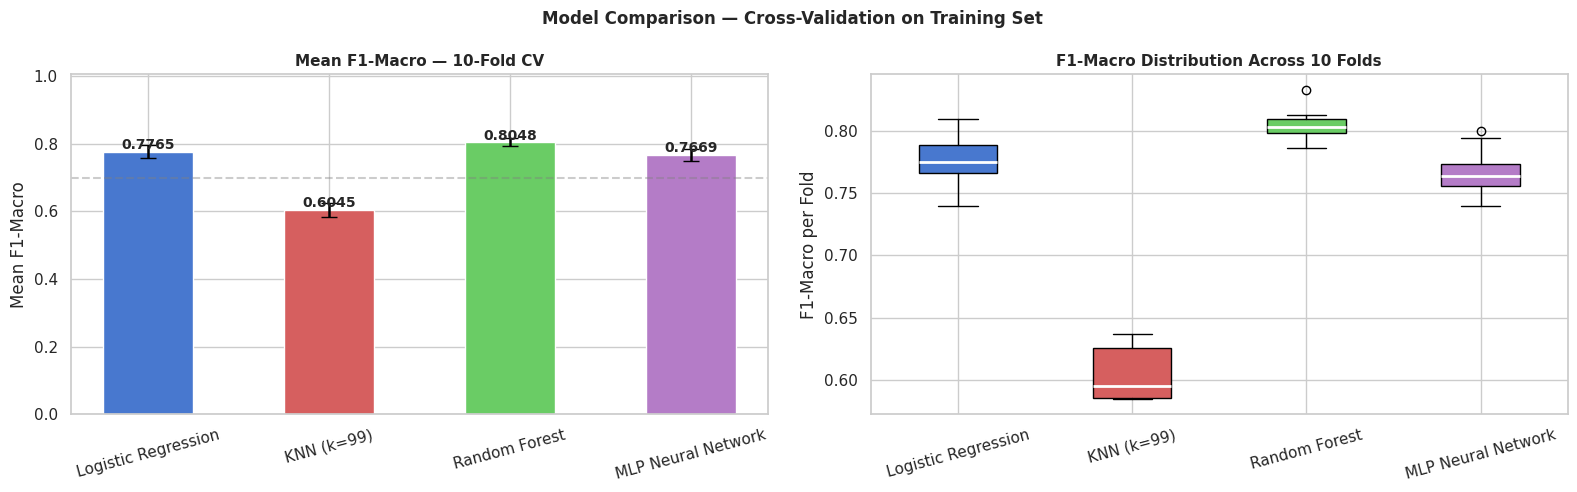

In [ ]:
model_names = [
    'Logistic Regression',
    f'KNN (k={k_value})',
    'Random Forest',
    'MLP Neural Network'
]

cv_means = [
    lr_fscore.mean(),
    knn_fscore.mean(),
    rf_fscore.mean(),
    mlp_fscore.mean()
]

cv_stds = [
    lr_fscore.std(),
    knn_fscore.std(),
    rf_fscore.std(),
    mlp_fscore.std()
]

colors = ['#4878CF', '#D65F5F', '#6ACC65', '#B47CC7']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Mean F1 bar chart with error bars
bars = axes[0].bar(model_names, cv_means, color=colors, edgecolor='white', width=0.5)
axes[0].errorbar(model_names, cv_means, yerr=cv_stds,
                 fmt='none', color='black', capsize=6, linewidth=1.8)

for bar, v in zip(bars, cv_means):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.008,
        f'{v:.4f}',
        ha='center',
        fontweight='bold',
        fontsize=10
    )

axes[0].set_title('Mean F1-Macro — 10-Fold CV', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Mean F1-Macro')
axes[0].set_ylim(0, max(cv_means) * 1.25)
axes[0].axhline(0.7, color='gray', linestyle='--', alpha=0.4)
axes[0].tick_params(axis='x', rotation=15)

# Box plot of fold scores
bp = axes[1].boxplot(
    [lr_fscore, knn_fscore, rf_fscore, mlp_fscore],
    labels=model_names,
    patch_artist=True,
    medianprops={'color': 'white', 'linewidth': 2}
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

axes[1].set_title('F1-Macro Distribution Across 10 Folds', fontsize=11, fontweight='bold')
axes[1].set_ylabel('F1-Macro per Fold')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Model Comparison — Cross-Validation on Training Set',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 7 — Final Model

Based on cross-validation, **Random Forest** achieved the best F1-Macro on the training set.  
We now fit the final model on the full training set and evaluate **exactly once** on the test set.

> This is the **first and only time** the test set predictions are examined.

In [ ]:
# Fit final model on full training set
rf_final = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_final.fit(Xtrain, ytrain)

RandomForestClassifier(class_weight='balanced', max_depth=15, n_estimators=200,
                       n_jobs=-1, random_state=42)

In [ ]:
yhat = rf_final.predict(Xtest)

In [ ]:
# Classification report — full metrics breakdown
print('=== FINAL MODEL — RANDOM FOREST — TEST SET RESULTS ===')
evaluate_model(rf_final, ytest, Xtest)

=== FINAL MODEL — RANDOM FOREST — TEST SET RESULTS ===
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      2059
           1       0.68      0.68      0.68       382

    accuracy                           0.90      2441
   macro avg       0.81      0.81      0.81      2441
weighted avg       0.90      0.90      0.90      2441



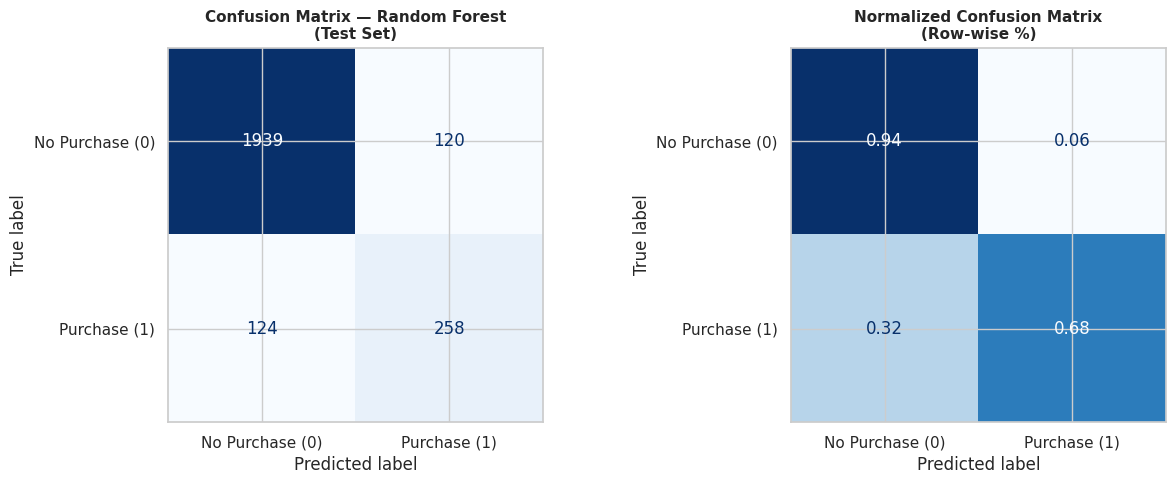

TP=258 | TN=1,939 | FP=120 | FN=124

Interpretation:
  Correctly identified buyers (TP):      258 out of 382 actual buyers (67.5%)
  Missed buyers (FN — False Negatives):  124  ← most costly error in practice
  False alarms (FP — False Positives):   120


In [ ]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(ytest, yhat)
tn, fp, fn, tp = cm.ravel()

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Purchase (0)', 'Purchase (1)']
)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Random Forest\n(Test Set)', fontsize=11, fontweight='bold')

# Normalized confusion matrix
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp_norm = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm.round(2),
    display_labels=['No Purchase (0)', 'Purchase (1)']
)
disp_norm.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Normalized Confusion Matrix\n(Row-wise %)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'TP={tp:,} | TN={tn:,} | FP={fp:,} | FN={fn:,}')
print()
print('Interpretation:')
print(f'  Correctly identified buyers (TP):      {tp:,} out of {tp+fn:,} actual buyers ({tp/(tp+fn)*100:.1f}%)')
print(f'  Missed buyers (FN — False Negatives):  {fn:,}  ← most costly error in practice')
print(f'  False alarms (FP — False Positives):   {fp:,}')

In [ ]:
print('=== FINAL MODEL PERFORMANCE SUMMARY ===')
print(f'  Model:         Random Forest')
print(f'  n_estimators:  200 trees')
print(f'  max_depth:     15')
print(f'  Train size:    {len(Xtrain):,} sessions')
print(f'  Test size:     {len(Xtest):,} sessions')
print()
print(f'  Accuracy:      {accuracy_score(ytest, yhat):.4f}')
print(f'  Precision:     {precision_score(ytest, yhat):.4f}')
print(f'  Recall:        {recall_score(ytest, yhat):.4f}')
print(f'  F1-Score:      {f1_score(ytest, yhat):.4f}')

=== FINAL MODEL PERFORMANCE SUMMARY ===
  Model:         Random Forest
  n_estimators:  200 trees
  max_depth:     15
  Train size:    9,764 sessions
  Test size:     2,441 sessions

  Accuracy:      0.9000
  Precision:     0.6825
  Recall:        0.6754
  F1-Score:      0.6789
